At first we'll build a model to predict survival on the Titanic, so let's get the data.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv' 
df = pd.read_csv(url)

df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df.dropna(inplace=True)

C:\Users\injik\AppData\Local\Temp\ipykernel_56492\520699123.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


Now let's define our X and y features, split the data and train the model.

In [3]:
X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


As the model is now trained, we'll make some predictions.

In [4]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8044692737430168


I'll just leave this model for now, and we'll come back to this later. Now we've got something called the Metrics Calculator. What it means is that we got a model that was tested on a set of 100 patient records to predict a disease, and the results are summarized in this matrix:

In [5]:
m = {
    "Predicted: No Disease": [85, 8],
    "Predicted: Disease": [5, 2]
}

matrix = pd.DataFrame(m)
matrix.index = ["Actual: No Disease", "Actual: Disease"]
print(matrix)

                    Predicted: No Disease  Predicted: Disease
Actual: No Disease                     85                   5
Actual: Disease                         8                   2


Based on this matrix we can say that our

TP = 85<br>
FP = 5<br>
FN = 8<br>
TN = 2<br>

Which means that

Accuracy = (85 + 2) / 100 = 87%<br>
Precision = TP/(TP + FP) = 85/(85 + 5) = 0.9444...<br>
Recall = TP/(TP + FN) = 85/(85 + 8) = 0.9139...<br>
F1 = 2 * (Precision * Recall)/(Precision + Recall) = 0.9288...<br>

So back to our model. Let's evaluate it properly this time.

In [6]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



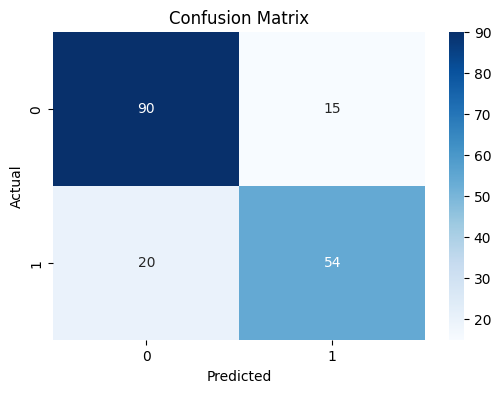

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

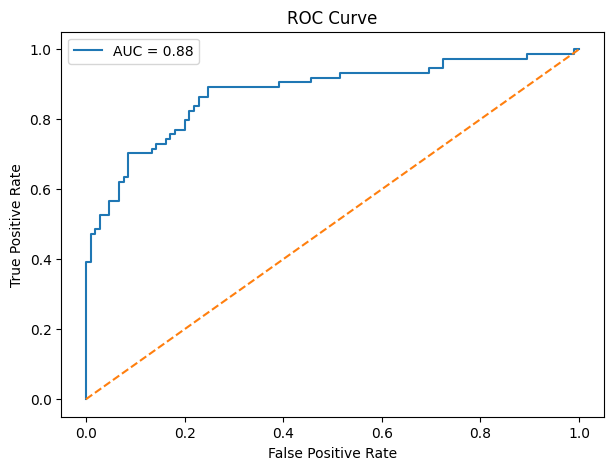

In [8]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

To imagine a real-world scenario, there can be times when Precision is more important than Recall, such as fraud detection, spam filtering or a product's quality detection. But there can also be times when Recall is more important, such as threat detection (not only in medicine, but in airport screenings for example), rare event detection (system failures for example) or search engine information retrieval.